<a href="https://colab.research.google.com/github/dsoria11/av-womd/blob/main/notebooks/WOD_TestRun.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install the waymo library

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install --upgrade pip setuptools wheel
!pip install waymo-open-dataset-tf-2-12-0 --no-deps  # Bypass strict old dependencies to avoid numpy build errors

Grabbing a 20-second traffic moment scenario and plotting the Autonomous Vehicles (AVs), external vehicles, cyclists, and pedestrians paths in different colors

/tmp/ipykernel_6660/754262659.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  vehicle_colors = cm.get_cmap('tab20', 20)


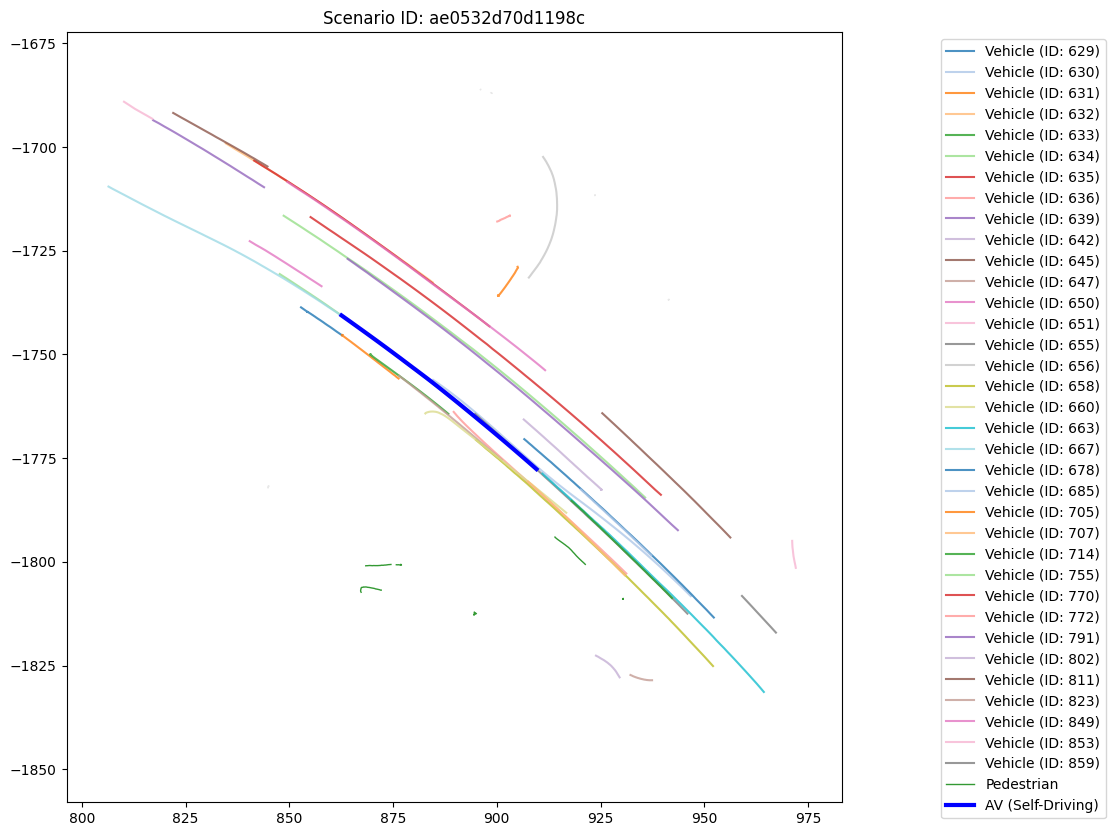

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import os
from waymo_open_dataset.protos import scenario_pb2

# Using the manually uploaded dataset file
FILENAME = '/content/drive/MyDrive/WODfiles/uncompressed_scenario_validation_validation.tfrecord-00001-of-00150'

# Loading the dataset
dataset = tf.data.TFRecordDataset(FILENAME)

# Creating a colormap to give each vehicle a unique color
vehicle_colors = cm.get_cmap('tab20', 20)
v_count = 0

# Extracting the first scenario
for raw_record in dataset.take(1):
    scenario = scenario_pb2.Scenario()
    scenario.ParseFromString(bytearray(raw_record.numpy()))

    plt.figure(figsize=(10, 10))

# Use enumerate() to get the index 'i' alongside the track
for i, track in enumerate(scenario.tracks):
    x = [state.center_x for state in track.states if state.valid]
    y = [state.center_y for state in track.states if state.valid]

    if not x: continue

    # Calculating a rough bounding box to see if object actually moves (aka remove parked vehicles)
    movement_spread = (max(x) - min(x)) + (max(y) - min(y))

    # Compare the INDEX (i) to the sdc_track_index

    # For AV's (autonomous vehicle)?
    if i == scenario.sdc_track_index:
        color, alpha, linewidth, label, zorder = 'blue', 1, 3, 'AV (Self-Driving)', 10

    # For other vehicle's (we give each a unique ID and color)
    elif track.object_type == scenario_pb2.Track.TYPE_VEHICLE:
      if (movement_spread < 1.0):
        color, alpha, linewidth, zorder = 'lightgrey', 0.5, 1, 1 # To make parked cars subtle (grayed out)
        label = '_nolegend_' # hides these labels from legend
      else:
        color = vehicle_colors(v_count % 20) #cycles through 20 colors
        alpha, linewidth, zorder = 0.8, 1.5, 5
        label = f'Vehicle (ID: {track.id})'
        v_count += 1

    # For pedestrians
    elif track.object_type == scenario_pb2.Track.TYPE_PEDESTRIAN:
        color, alpha, linewidth, label, zorder = 'green', 0.8, 1, 'Pedestrian', 5

    # For cyclists
    elif track.object_type == scenario_pb2.Track.TYPE_CYCLIST:
        color, alpha, linewidth, label, zorder = 'orange', 0.8, 1, 'Cyclist', 5
    else:
        color, alpha, linewidth, label, zorder = 'grey', 0.2, 1, 'Unknown', 0

    # Draw the line
    plt.plot(x, y, color=color, alpha=alpha, linewidth=linewidth, label=label, zorder=zorder)

# Render Legend and Plot
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='upper right', bbox_to_anchor=(1.35, 1))

plt.title(f"Scenario ID: {scenario.scenario_id}")
plt.axis('equal')
plt.show()

Making the coordinates centered around the agent (the AV) to gather velocities, acceleration, distances, etc,.

In [ ]:
import numpy as np

class CoordinateTransformer:
    def __init__(self, states):
        """
        states: A list of Waymo 'state' objects for a single agent.
        We find the first valid state to define the origin and orientation.
        """
        self.origin_x = None
        self.origin_y = None
        self.heading = None

        # Find the first valid state to set the Agent-Centric Origin (t=0)
        for state in states:
            if state.valid:
                self.origin_x = state.center_x
                self.origin_y = state.center_y
                self.heading = state.heading
                break

        # Calculate rotation matrix to face North (Pi/2)
        if self.heading is not None:
            theta = (np.pi / 2) - self.heading
            self.cos_theta = np.cos(theta)
            self.sin_theta = np.sin(theta)

    def transform(self, x, y):
        """Translates and rotates a single x, y coordinate."""
        if self.origin_x is None: return x, y

        # Translate
        tx = x - self.origin_x
        ty = y - self.origin_y

        # Rotate
        rx = tx * self.cos_theta - ty * self.sin_theta
        ry = tx * self.sin_theta + ty * self.cos_theta

        return rx, ry

In [ ]:
import pandas as pd

# Store the extracted features in a list, then convert to a DataFrame
feature_list = []

for track in scenario.tracks:
    # Only processing agents that have valid states
    valid_states = [s for s in track.states if s.valid]
    if not valid_states:
        continue

    # Initialize our Transformer based on this specific agent's starting position
    transformer = CoordinateTransformer(valid_states)

    # Lists to hold the different physiccal features for this agent
    velocities = []
    accelerations = []
    agent_x_path = []
    agent_y_path = []

    for state in valid_states:
        # Transform the coordinates so the agent starts at 0,0 facing North
        rx, ry = transformer.transform(state.center_x, state.center_y)
        agent_x_path.append(rx)
        agent_y_path.append(ry)

        # Calculating velocity (Waymo provides velocity directly in states)
        v = np.sqrt(state.velocity_x**2 + state.velocity_y**2)
        velocities.append(v)

    # Calculating different features (max velocity, acceleration, etc.)
    max_v = max(velocities) if velocities else 0
    # Acceleration is the change in velocity (dv/dt). Waymo samples at 10Hz (0.1s)
    accels = np.diff(velocities) / 0.1
    max_a = max(accels) if len(accels) > 0 else 0
    min_a = min(accels) if len(accels) > 0 else 0 # Minimum acceleration (braking)

    # Calculate Total Distance Traveled
    distance = sum(np.sqrt(np.diff(agent_x_path)**2 + np.diff(agent_y_path)**2))

    # Map Waymo's Object Type Enum to readable strings
    type_map = {1: 'Vehicle', 2: 'Pedestrian', 3: 'Cyclist'}
    obj_type = type_map.get(track.object_type, 'Other')

    feature_list.append({
        'Agent_ID': track.id,
        'Type': obj_type,
        'Max_Velocity (m/s)': max_v,
        'Max_Accel (m/s^2)': max_a,
        'Max_Brake (m/s^2)': min_a,
        'Total_Distance (m)': distance
    })

# Converting to Pandas DataFrame
df_features = pd.DataFrame(feature_list)
print(df_features.head(10))

   Agent_ID     Type  Max_Velocity (m/s)  Max_Accel (m/s^2)  \
0       629  Vehicle            4.558413           6.714974   
1       630  Vehicle           15.429574           5.818108   
2       631  Vehicle            7.740831          35.911273   
3       632  Vehicle           13.526490           6.166759   
4       633  Vehicle            6.761927           7.122120   
5       634  Vehicle            8.337937           4.599495   
6       635  Vehicle           13.140461           9.596487   
7       636  Vehicle            9.493384           3.745228   
8       637  Vehicle            0.000000           0.000000   
9       638  Vehicle            0.000000           0.000000   

   Max_Brake (m/s^2)  Total_Distance (m)  
0          -4.569865           12.033352  
1          -4.481896           81.147214  
2         -24.139521           17.429521  
3          -7.353251           60.108219  
4          -3.777099           23.677040  
5          -4.954784           61.338626  
6    

Scaling (so ML agent doesnt get confused and think distance is the only thing that matters)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pandas as pd

# Isolating different physical features
features = ['Max_Velocity (m/s)', 'Max_Accel (m/s^2)', 'Max_Brake (m/s^2)', 'Total_Distance (m)'] # Excluding Agent_ID and Type so AI doesn't pay attention to human labels
X = df_features[features]

# Normalizing data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Sorting (k-means where k = 4)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

# ML model predicts a cluster (0, 1, 2 or 3) for every agent
df_features['Cluster'] = kmeans.fit_predict(X_scaled)

# Results of predictions of what AI discovered
print("### Physics of each cluster ###")
cluster_centroid = df_features.groupby('Cluster')[features].mean() # shows the average position of each cluster
print(cluster_centroid)

print("### Final Predictions ###")
cross_check = pd.crosstab(df_features['Cluster'], df_features['Type'])
print(cross_check)


### Physics of each cluster ###
         Max_Velocity (m/s)  Max_Accel (m/s^2)  Max_Brake (m/s^2)  \
Cluster                                                             
0                  7.105995           8.312765          -8.580244   
1                  0.056911           0.203745          -0.161175   
2                 13.665641           7.782949          -6.804599   
3                 10.720483          26.499623         -36.001864   

         Total_Distance (m)  
Cluster                      
0                 17.389378  
1                  0.083331  
2                 71.789914  
3                 29.895718  
### Final Predictions ###
Type     Pedestrian  Vehicle
Cluster                     
0                 2       18
1                 3      165
2                 0       16
3                 1        3


More than likely:

1.   Cluster 1 represents stationary agents
2.   Cluster 2 represents fast moving agents
3.   Cluster 3 and 4 represent really fast-moving agents (? doesn't make sense - might be a glitch in waymos dataset)

**Look at how to filter out the impossible physics sensor data






To visualize the clusters (4D)

